In [ ]:
import importlib
from interface import python_interface as api
import numpy as np
importlib.reload(api)
cpar=api.example_cpar()
cpar['rho_0'] = 972.47 - 157.24 * np.power(cpar['nu_L'],-0.6649) #kg/m^3
cpar['mu_L'] = cpar['nu_L'] * 1.0e-6 * cpar['rho_0']
cpar['c_0'] = 1001.86 - 83.97 * np.power(cpar['nu_L'],-0.6281) #m/s
cpar['sigma_var'] = (21.1750-3.9579* np.power(cpar['nu_L'],-0.6163))*0.001 #mN/m -> N/m
cpar['B_L'] = cpar['rho_0'] * cpar['c_0'] * cpar['c_0'] / cpar['Gamma_L']

data=api.run_simulation(cpar,executable_path="./bin/main",t_max=0.0001,timeout=60.0,save_steps=True)
#cpar: dict, json_path: str = 'ignore.json', executable_path: str = './bin/main', t_max: float = 1.0, timeout: float = 60.0, save_steps: bool = True, save_jacobian: bool = False, show_output: bool = True
api.plot(data)

class dotdict(dict):
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

import importlib   # For reloading your own files
import full_bubble_model as de
importlib.reload(de)
import parameters as par   # numeric constants and coefficents
importlib.reload(par)   # reload changes you made
file = de.Make_dir('_test', separator=',')   # it makes a folder named 'test' in which it will save data
num_sol=data['sol']
error_code=-1
elapsed_time=-1

num_sol = dotdict(data['sol'])
num_sol.y = num_sol.x.T.copy()
#num_sol.y[3:-1,:] = num_sol.y[3:-1,:]*1.0e-6#*1.0e-6: mol/m^3->mol/cm^3
#!!!! data.success = num_sol.success

data2 = de.get_data(cpar, num_sol, error_code, elapsed_time)   # post processing
data2.t_E = data['t_E']
data2.mu_L= data['cpar']['mu_L']
data2.rho_0=data['cpar']['rho_0']
data2.c_0=data['cpar']['c_0']
data2.sigma_var=data['cpar']['sigma_var']
data2.EoS_liquid = data['cpar']['EoS_liquid']
file.write_solution(data2, num_sol, 'testfile')   # saving (it overwrites data)

In [ ]:
import importlib
from interface import python_interface as api
import numpy as np
importlib.reload(api)

ps=api.example_parameter_study()

rho_0 = 972.47 - 157.24 * np.power(ps['nu_L']['value'],-0.6649) #kg/m^3
mu_L = ps['nu_L']['value'] * 1.0e-6 * rho_0
c_0 = 1001.86 - 83.97 * np.power(ps['nu_L']['value'],-0.6281) #m/s
sigma_var = (21.1750-3.9579 * np.power(ps['nu_L']['value'],-0.6163))*0.001 #mN/m -> N/m

ps['B_L'] = {"type": "Const", "value": rho_0 * c_0 * c_0 / ps['Gamma_L']['value']}

ps['mu_L'] = {"type": "Const", "value": mu_L} #0.001
ps['rho_0'] = {"type": "Const", "value": rho_0} #998.2
ps['c_0'] = {"type": "Const", "value": c_0} #1483.0
ps['sigma_var'] = {"type": "Const", "value": sigma_var} #0.07197 for water

api.run_parameter_study(ps,t_max=0.01,timeout=60.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

executable_path='./bin/main', system='wsl'
executable_path='./bin/main', system='wsl'
test.csv
Please check, where you R_dotdot read in from!
{'ID': 0, 'mechanism': 'KAUST2023_N2_C0_CKMC_ESR_v10_0_oxygenless', 'R_E': 0.000174752840000768, 'ratio': 1.0, 'species': ['H2', 'N2'], 'fractions': [0.75, 0.25], 'P_amb': 200000.0, 'T_inf': 298.15, 'alpha_M': 0.35, 'P_v': 2338.1, 'mu_L': 0.004592707786509389, 'nu_L': 5.0, 'rho_0': 918.541557301878, 'c_0': 971.3036769078105, 'sigma_var': 0.019707123210014214, 'surfactant': 1.0, 'enable_heat_transfer': True, 'enable_evaporation': False, 'enable_reactions': True, 'enable_dissipated_energy': True, 'enable_van_der_waals': True, 'enable_rate_thresholding': True, 'target_specie': 'NH3', 'excitation_type': 'sinusoid', 'excitation_params': [-351515.151515151, 10000.0], 'excitation_cycles': 1.0, 'ramp_up_cycles': 0.0, 'R_and_R_dot_from_file': 0, 'rows': 1, 'cols': 1, 'file_name': 'test.csv', 'const_V': 0, 'const_T': 0, 'EoS_liquid': 'Tait', 'Gamma_L': 8.4

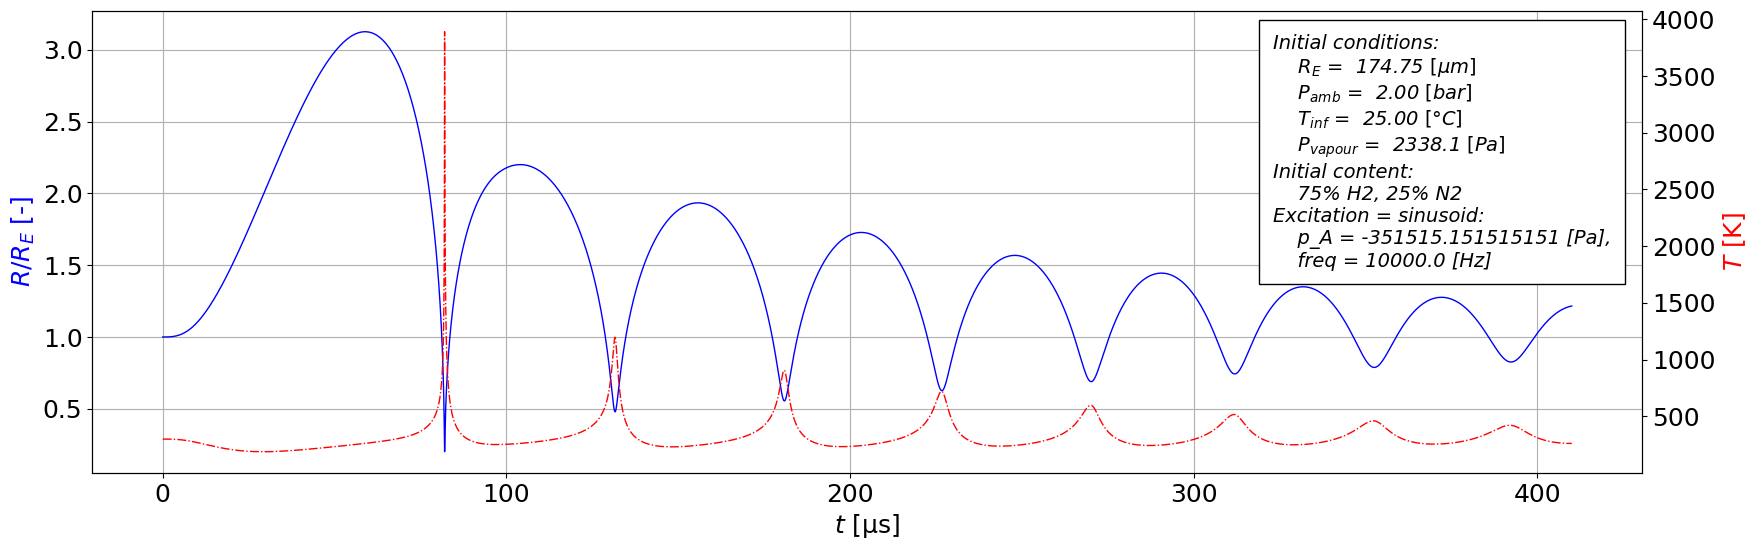

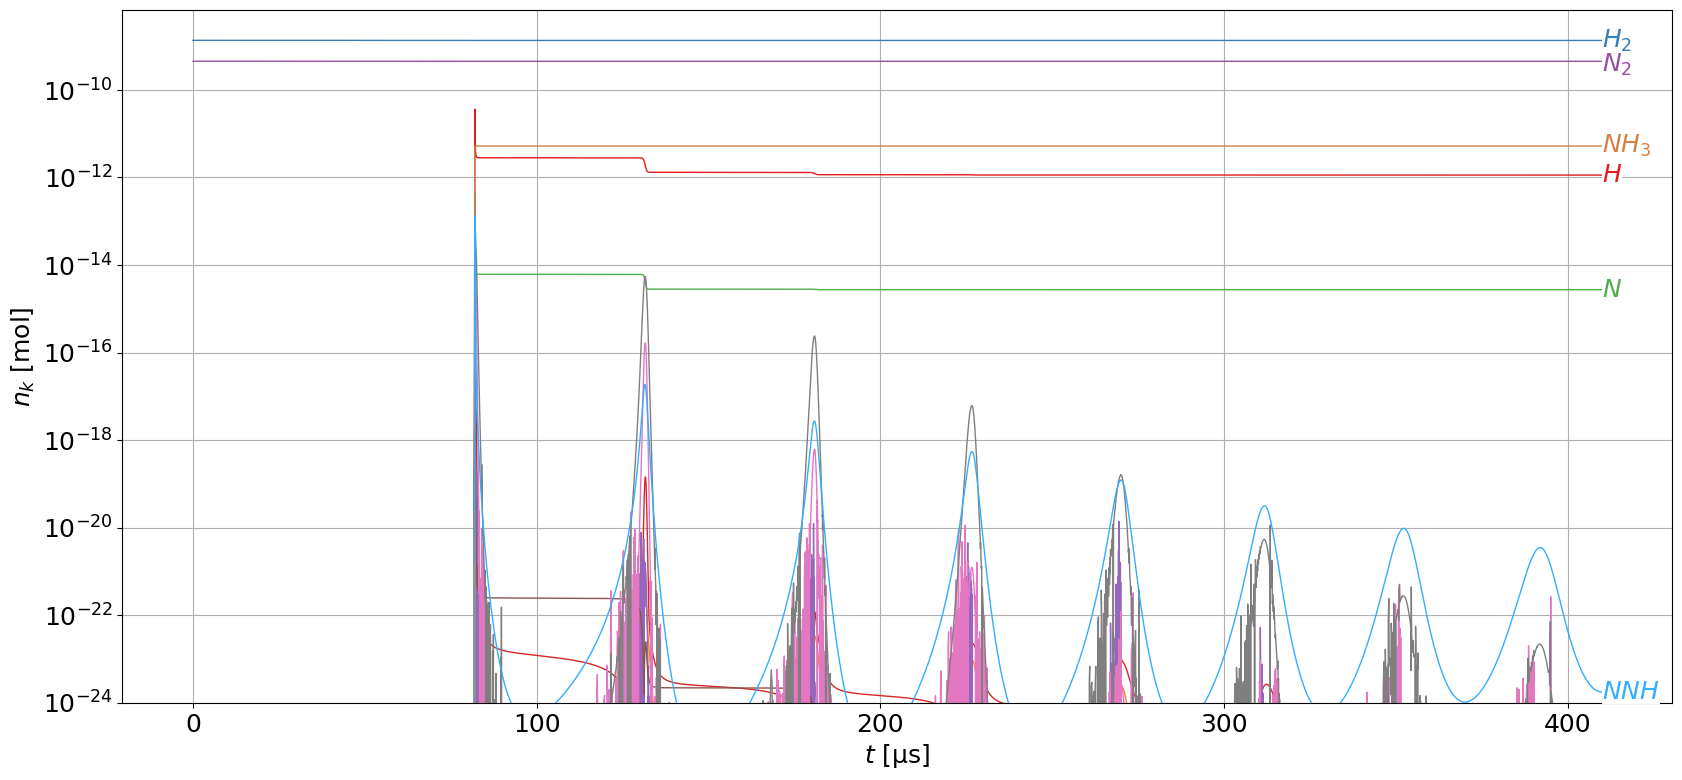

Control Parameters:
  ID: 0
  Mechanism: KAUST2023_N2_C0_CKMC_ESR_v10_0_oxygenless
  R_E: 174.752840000768 [um]
  Ratio: 1.0 [-]
  Species: ['H2', 'N2']
  Fractions: [0.75, 0.25]
  P_amb: 200000.0 [Pa]
  T_inf: 298.15 [K]
  alpha_M: 0.35 [-]
  P_v: 2338.1 [Pa]
  mu_L: 0.004592707786509389 [Pa·s]
  rho_L: 998.2 [kg/m³]
  c_L: 1483.0 [m/s]
  Surfactant: 1.0
  Bubble Dynamics: keller_miksis
  Liquid EOS Params: []
  Enable Heat Transfer: True
  Enable Evaporation: False
  Enable Reactions: True
  Enable Dissipated Energy: True
  Enable Van der Waals: True
  Enable Rate Thresholding: True
  Target Specie: NH3
  Excitation Type: sinusoid
  Excitation Params: [-351515.151515151, 10000.0]
  Excitation Cycles: 1.0 [-]
  Ramp Up Cycles: 0.0 [-]

Simulation Info:
  Success: True
  Error: 2026.09.16 12:59:03: INFO (general) No error occured in ./src/common.cpp:291: get_error();
  Runtime: 0.135 [s]
  Num Steps: 10320
  Num Repeats: 470
  Num Function Evaluations: 35529
  Num Jacobian Evaluations:

In [1]:
import importlib
from interface import python_interface as api
import numpy as np
importlib.reload(api)
cpar=api.example_cpar()

cpar = {'ID': 0,
 'mechanism': 'KAUST2023_N2_C0_CKMC_ESR_v10_0_oxygenless',#'chemkin_kaust2023_ammonia_oxygenless',
 'R_E': 174.752840000768e-06, #0.000187381742286039,#53.3669923120631e-6,#40.0e-06, #0.0621,
 'ratio': 1.0,
 'species': ['H2','N2'],#['H2','N2','O2','AR','HE','H2O'],#['N2H3','O','NH2','NO','H'],
 'fractions': [0.75,0.25],#[0.25,0.20,0.05,0.07,0.12,0.31],#[0.3,0.25,0.2,0.15,0.1],
 'P_amb': 2.0e5,#101325.0, #1000.0e5,
 'T_inf': 298.15, #5000.0,
 'alpha_M': 0.35,
 'P_v': 2338.1,
 'mu_L': 0.001,#-1.0,#
 'nu_L': 5.0, #cSt
 'rho_0': 998.2, #-1.0,#
 'c_0': 1483.0,#-1.0,#
 'sigma_var': 0.0728,#-1.0,
 'surfactant': 1.0,
 'enable_heat_transfer': True,
 'enable_evaporation': False,
 'enable_reactions': True,
 'enable_dissipated_energy': True,
 'enable_van_der_waals': True,
 'enable_rate_thresholding': True,
 'target_specie': 'NH3',
 'excitation_type': 'sinusoid',#'no_excitation',
 'excitation_params': [-3.51515151515151e5,10.0e3],#[-9545454.54545454,100.0e3],#[-19.2323232323232e5, 100.0e3],#[-1.808080808080808e5, 25.353644939701141e3],#[-2.12121e5, 45.4031e3],# [], 
 'excitation_cycles': 1.0,
 'ramp_up_cycles': 0.0,
 'R_and_R_dot_from_file': 0, #0: nothing to read in, chemistry is coupled to bubble dynamics; 1: R is read in, R_dot is calculated from the Lagrange interpolation polynomial
 'rows': 1,
 'cols': 1,
 'file_name': 'test.csv',#'R40_Minimal_P1.8_ALPACA_O2N9R5.csv',#'R40_Minimal_P1.8_ALPACA_O2N9.csv',#'test.csv', #'R40_Minimal_P1.8_ALPACA.csv',#'R40_Minimal_P1.8_nincskemia_kidolgozva.csv',#'R40_Qon_ALPACA_fine_kidolgozva.csv'
 'const_V' : 0,      # 0: V is not constant, 1: V is constant";
 'const_T' : 0, # 0: T is not constant, 1: T is constant";
 'EoS_liquid': 'Tait', #'Tait' or 'NASG'
 'Gamma_L': 8.4207,
 'B_L': -1.0,
 'b_L': 0.000672
       }

cpar['rho_0'] = 972.47 - 157.24 * np.power(cpar['nu_L'],-0.6649) #kg/m^3
cpar['mu_L'] = cpar['nu_L'] * 1.0e-6 * cpar['rho_0']
cpar['c_0'] = 1001.86 - 83.97 * np.power(cpar['nu_L'],-0.6281) #m/s
cpar['sigma_var'] = (21.1750-3.9579* np.power(cpar['nu_L'],-0.6163))*0.001 #mN/m -> N/m
cpar['B_L'] = cpar['rho_0'] * cpar['c_0'] * cpar['c_0'] / cpar['Gamma_L']

print(cpar['file_name'])
print('Please check, where you R_dotdot read in from!')

print(cpar)

data=api.run_simulation(cpar,executable_path="./bin/main",t_max=1.0,timeout=60.0,save_steps=True)
#cpar: dict, json_path: str = 'ignore.json', executable_path: str = './bin/main', t_max: float = 1.0, timeout: float = 60.0, save_steps: bool = True, save_jacobian: bool = False, show_output: bool = True
api.plot(data)


ps=api.example_parameter_study()

ps['mechanism'] = 'chemkin_kaust2023_ammonia_oxygenless'
ps['R_E'] = {"type":"LogRange","start": 1.0e-6,"end":200.0e-6,"num_steps":100}#{"type": "Const", "value": 0.0621}#40.0e-6}
ps['ratio'] = {"type": "Const", "value": 1.0}
ps['species'] = ['H2','N2']
ps['fractions'] = [0.75,0.25]
ps['alpha_M'] = {"type": "Const", "value": 0.35}
ps['P_v'] = {"type": "Const", "value": 2338.1}

ps['P_amb'] =  {"type": "Const", "value": 1.0e5}#{"type":"LogRange","start":1.0e5,"end":1.0e10,"num_steps":2}#
ps['T_inf'] =  {"type": "Const", "value": 298.15}#{"type":"LinearRange","start":1000,"end":6000,"num_steps":2}#
#ps['nu_L'] = {"type": "Const", "value": 0.65} #{"type":"LinearRange","start":0.1,"end":0.3,"num_steps":10}#
#ps['mu_L'] = {"type": "Const", "value": -1.0} #0.001

#ps['rho_0'] = {"type": "Const", "value": -1.0} #998.2
#ps['c_0'] = {"type": "Const", "value": -1.0} #1483.0
#ps['sigma_var'] = {"type": "Const", "value": -1.0} #0.07197 for water
ps['surfactant'] = {"type": "Const", "value": 1.0}
ps['enable_heat_transfer'] = True
ps['enable_evaporation'] = False
ps['enable_reactions'] = True
ps['enable_dissipated_energy'] = True
ps['enable_van_der_waals'] = True
ps['enable_rate_thresholding'] = True
ps['target_specie'] = 'NH3'
ps['excitation_type'] = 'sinusoid'
ps['excitation_params'] = [
    {"type":"LinearRange","start":-1.0e5,"end":-4.0e5,"num_steps":100},#100      -2.12121e5}, #p_A
    #{"type":"LogRange","start":10.0e3,"end":100.0e3,"num_steps":100}#
    {"type": "Const", "value": 10.0e3}#  #freq
]
ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
ps['rows'] = {"type": "Const", "value": 1.0}
ps['cols'] = {"type": "Const", "value": 1.0}
ps['file_name'] = 'test.csv'
ps['const_V'] = {"type": "Const", "value": 0.0}
ps['const_T'] = {"type": "Const", "value": 0.0}
ps['EoS_liquid'] = 'Tait'
#ps['b_L'] = 
Gamma_L = 8.4207
ps['Gamma_L'] = {"type": "Const", "value": Gamma_L}

nu_L = 5.0#0.65#50.0
ps['nu_L'] = {"type": "Const", "value": nu_L} #{"type":"LinearRange","start":0.1,"end":0.3,"num_steps":10}#

rho_0 = 972.47 - 157.24 * np.power(nu_L,-0.6649) #kg/m^3
mu_L = nu_L * 1.0e-6 * rho_0
c_0 = 1001.86 - 83.97 * np.power(nu_L,-0.6281) #m/s
sigma_var = (21.1750-3.9579 * np.power(nu_L,-0.6163))*0.001 #mN/m -> N/m

ps['B_L'] = {"type": "Const", "value": rho_0 * c_0 * c_0 / Gamma_L}

ps['mu_L'] = {"type": "Const", "value": mu_L} #0.001
ps['rho_0'] = {"type": "Const", "value": rho_0} #998.2
ps['c_0'] = {"type": "Const", "value": c_0} #1483.0
ps['sigma_var'] = {"type": "Const", "value": sigma_var} #0.07197 for water

#api.run_parameter_study(ps,save_directory='par_study')

#datas=api.read_parameter_study('par_study1/')

#api.run_parameter_study(ps,t_max=1.0,timeout=60.0) #,save_directory='par_study'

#datas=api.read_parameter_study('par_study1/')

In [ ]:
api.run_parameter_study(ps,t_max=1.0e-7,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=1.0e-6,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')
api.run_parameter_study(ps,t_max=1.0e-5,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')
api.run_parameter_study(ps,t_max=1.0e-4,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')
api.run_parameter_study(ps,t_max=1.0e-3,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=1.0e-2,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=1.0e-1,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=1.0,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=10.0,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=100.0,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

api.run_parameter_study(ps,t_max=1000.0,timeout=3000.0) #,save_directory='par_study'

datas=api.read_parameter_study('par_study1/')

In [ ]:
print('Please check if the data in parameters.py is correct (accurate mechanism...)!')
class dotdict(dict):
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

import importlib   # For reloading your own files
import full_bubble_model as de
importlib.reload(de)
import parameters as par   # numeric constants and coefficents
importlib.reload(par)   # reload changes you made
file = de.Make_dir('_test', separator=',')   # it makes a folder named 'test' in which it will save data
num_sol=data['sol']
error_code=-1
elapsed_time=-1

num_sol = dotdict(data['sol'])
num_sol.y = num_sol.x.T.copy()
#num_sol.y[3:-1,:] = num_sol.y[3:-1,:]*1.0e-6#*1.0e-6: mol/m^3->mol/cm^3
#!!!! data.success = num_sol.success

data2 = de.get_data(cpar, num_sol, error_code, elapsed_time)   # post processing
data2.t_E = data['t_E']
data2.mu_L= data['cpar']['mu_L']
data2.rho_0=data['cpar']['rho_0']
data2.c_0=data['cpar']['c_0']
data2.sigma_var=data['cpar']['sigma_var']
data2.EoS_liquid = data['cpar']['EoS_liquid']
file.write_solution(data2, num_sol, 'testfile')   # saving (it overwrites data)

In [ ]:
#nagy szimu:
P_amb = 2.0e5
import importlib
import os
import numpy as np
from interface import python_interface as api

importlib.reload(api)

from IPython.utils.capture import capture_output

with capture_output():
    # -----------------------------------------------------------------------------
    # 1. FIX PARAMÉTEREK ÉS TARTOMÁNYOK DEFINIÁLÁSA
    # -----------------------------------------------------------------------------
    # nu_L listája 0.65-től egészen 50 cSt-ig terjedhet
    nu_L_list = [0.65, 1.0, 5.0, 10.0, 50.0]  
    # Frekvencia lista 10 kHz-től 200 kHz-ig
    frequency_list = [10.0e3, 20.0e3,25.0e3,30.0e3, 50.0e3, 100.0e3, 200.0e3]  
    
    Gamma_L = 8.4207
    base_dir = "parameter_studies_max10bar"
    os.makedirs(base_dir, exist_ok=True)
    
    # -----------------------------------------------------------------------------
    # 2. EGYMÁSBA ÁGYAZOTT CIKLUSOK A SZIMULÁCIÓKHOZ
    # -----------------------------------------------------------------------------
    
    for f in frequency_list:
        for nu_L in nu_L_list:
            
            # Egyedi mappa név minden futtatásnak (pl. study_nu_50.0_f_200kHz)
            dir_name = f"{base_dir}/study_nu_{nu_L}_f_{int(f/1000)}kHz_"
            print(f"\n=== Szimuláció indítása: nu_L = {nu_L} cSt, f = {f/1000} kHz ===")
            print(f"Mentési könyvtár: {dir_name}")
    
            # Alap parameter study objektum lekérése
            ps = api.example_parameter_study()
    
            # Anyagtulajdonságok számítása nu_L alapján
            rho_0 = 972.47 - 157.24 * np.power(nu_L, -0.6649)
            mu_L = nu_L * 1.0e-6 * rho_0
            c_0 = 1001.86 - 83.97 * np.power(nu_L, -0.6281)
            sigma_var = (21.1750 - 3.9579 * np.power(nu_L, -0.6163)) * 0.001
            B_L = rho_0 * c_0 * c_0 / Gamma_L
    
            # --- DINAMIKUS TARTOMÁNY BEÁLLÍTÁSA (P_A és R_E) VÍZKOZITÁSRA ÉS FREKVENCIÁRA ---
            # Alapértelmezett (alacsony frekvenciás/alacsony viszkozitású) határok:
            r_start, r_end = 1.0e-6, 1000.0e-6
            p_start, p_end = -P_amb, -P_amb-10.0e5
    
            # 1. Frekvencia alapú alap-skálázás (főleg R_E-re és p_A alapra van hatással)
    #        if f <= 20.0e3:
    #            r_start, r_end = 1.0e-6, 200.0e-6
    #            p_start, p_end = -1.0e5, -6.0e5
    #        elif f <= 50.0e3:
    #            r_start, r_end = 0.5e-6, 100.0e-6
    #            p_start, p_end = -1.5e5, -10.0e5
    #        elif f <= 100.0e3:
    #            r_start, r_end = 0.2e-6, 50.0e-6
    #            p_start, p_end = -2.0e5, -15.0e5
    #        else:  # 200 kHz
    #            r_start, r_end = 0.1e-6, 25.0e-6
    #            p_start, p_end = -3.0e5, -25.0e5
    
            # 2. Viszkozitás (nu_L) miatti p_A korrekció (Nagyobb nu_L -> Drasztikusan mélyebb p_end kell)
            # Ha nu_L magas, a p_end-et (maximális negatív nyomást) megszorozzuk egy faktorral
    #        if nu_L > 1.0:
    #            # Egy tapasztalati szorzó: nu_L=50 esetén kb. 2.5-szeresére növeli meg a p_A tartomány végértékét
    #            viscosity_factor = 1.0 + 0.03 * nu_L  
    #            p_end = p_end * viscosity_factor
                
                # Magas viszkozitásnál a túl apró buborékok azonnal elnyomódnak, 
                # így az r_start-ot érdemes kicsit feljebb tolni, hogy ne fussunk felesleges köröket
    #            if f > 50.0e3:
    #                r_start = r_start * 1.5
    
            print(f"  Beállított R_E tartomány: {r_start*1e6:.2f} um - {r_end*1e6:.2f} um")
            print(f"  Beállított p_A tartomány: {p_start/1e5:.1f} bar - {p_end/1e5:.1f} bar")
    
            # --- PARAMÉTEREK HOZZÁRENDELÉSE ---
            ps['mechanism'] = 'chemkin_kaust2023_ammonia_oxygenless'
            ps['ratio'] = {"type": "Const", "value": 1.0}
            ps['species'] = ['H2', 'N2']
            ps['fractions'] = [0.75, 0.25]
            ps['alpha_M'] = {"type": "Const", "value": 0.35}
            ps['P_v'] = {"type": "Const", "value": 2338.1}
            ps['P_amb'] = {"type": "Const", "value": P_amb}
            ps['T_inf'] = {"type": "Const", "value": 298.15}
            
            ps['surfactant'] = {"type": "Const", "value": 1.0}
            ps['enable_heat_transfer'] = True
            ps['enable_evaporation'] = False
            ps['enable_reactions'] = True
            ps['enable_dissipated_energy'] = True
            ps['enable_van_der_waals'] = True
            ps['enable_rate_thresholding'] = True
            ps['target_specie'] = 'NH3'
            
            # Gerjesztés beállításai (a dinamikusan számolt p_start és p_end értékekkel)
            ps['excitation_type'] = 'sinusoid'
            ps['excitation_params'] = [
                {"type": "LinearRange", "start": p_start, "end": p_end, "num_steps": 100},  # p_A
                {"type": "Const", "value": f}  # f (ciklusból)
            ]
            ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
            ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
            
            # Változó tartomány R_E-re
            ps['R_E'] = {"type": "LogRange", "start": r_start, "end": r_end, "num_steps": 100}
            
            # Folyadék tulajdonságok (ciklusból számolva)
            ps['EoS_liquid'] = 'Tait'
            ps['Gamma_L'] = {"type": "Const", "value": Gamma_L}
            ps['nu_L'] = {"type": "Const", "value": nu_L}
            ps['B_L'] = {"type": "Const", "value": B_L}
            ps['mu_L'] = {"type": "Const", "value": mu_L}
            ps['rho_0'] = {"type": "Const", "value": rho_0}
            ps['c_0'] = {"type": "Const", "value": c_0}
            ps['sigma_var'] = {"type": "Const", "value": sigma_var}
    
            ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
            ps['rows'] = {"type": "Const", "value": 1.0}
            ps['cols'] = {"type": "Const", "value": 1.0}
            ps['file_name'] = 'test.csv'
            ps['const_V'] = {"type": "Const", "value": 0.0}
            ps['const_T'] = {"type": "Const", "value": 0.0}
    
            # --- SZIMULÁCIÓ FUTTATÁSA ---
            api.run_parameter_study(ps, t_max=1.0, timeout=60.0, save_directory=dir_name)
    
print("\nMinden szimuláció lefutott!")

In [ ]:
#nagy szimu:
P_amb = 2.0e5
import importlib
import os
import numpy as np
from interface import python_interface as api

importlib.reload(api)

from IPython.utils.capture import capture_output

with capture_output():
    # -----------------------------------------------------------------------------
    # 1. FIX PARAMÉTEREK ÉS TARTOMÁNYOK DEFINIÁLÁSA
    # -----------------------------------------------------------------------------
    # nu_L listája 0.65-től egészen 50 cSt-ig terjedhet
    nu_L_list = [0.65, 1.0, 5.0, 10.0, 50.0]  
    # Frekvencia lista 10 kHz-től 200 kHz-ig
    frequency_list = [10.0e3, 20.0e3,25.0e3,30.0e3, 50.0e3, 100.0e3, 200.0e3]  
    
    Gamma_L = 8.4207
    base_dir = "parameter_studies_max20bar"
    os.makedirs(base_dir, exist_ok=True)
    
    # -----------------------------------------------------------------------------
    # 2. EGYMÁSBA ÁGYAZOTT CIKLUSOK A SZIMULÁCIÓKHOZ
    # -----------------------------------------------------------------------------
    
    for f in frequency_list:
        for nu_L in nu_L_list:
            
            # Egyedi mappa név minden futtatásnak (pl. study_nu_50.0_f_200kHz)
            dir_name = f"{base_dir}/study_nu_{nu_L}_f_{int(f/1000)}kHz_"
            print(f"\n=== Szimuláció indítása: nu_L = {nu_L} cSt, f = {f/1000} kHz ===")
            print(f"Mentési könyvtár: {dir_name}")
    
            # Alap parameter study objektum lekérése
            ps = api.example_parameter_study()
    
            # Anyagtulajdonságok számítása nu_L alapján
            rho_0 = 972.47 - 157.24 * np.power(nu_L, -0.6649)
            mu_L = nu_L * 1.0e-6 * rho_0
            c_0 = 1001.86 - 83.97 * np.power(nu_L, -0.6281)
            sigma_var = (21.1750 - 3.9579 * np.power(nu_L, -0.6163)) * 0.001
            B_L = rho_0 * c_0 * c_0 / Gamma_L
    
            # --- DINAMIKUS TARTOMÁNY BEÁLLÍTÁSA (P_A és R_E) VÍZKOZITÁSRA ÉS FREKVENCIÁRA ---
            # Alapértelmezett (alacsony frekvenciás/alacsony viszkozitású) határok:
            r_start, r_end = 1.0e-6, 1000.0e-6
            p_start, p_end = -P_amb, -P_amb-20.0e5
    
            # 1. Frekvencia alapú alap-skálázás (főleg R_E-re és p_A alapra van hatással)
    #        if f <= 20.0e3:
    #            r_start, r_end = 1.0e-6, 200.0e-6
    #            p_start, p_end = -1.0e5, -6.0e5
    #        elif f <= 50.0e3:
    #            r_start, r_end = 0.5e-6, 100.0e-6
    #            p_start, p_end = -1.5e5, -10.0e5
    #        elif f <= 100.0e3:
    #            r_start, r_end = 0.2e-6, 50.0e-6
    #            p_start, p_end = -2.0e5, -15.0e5
    #        else:  # 200 kHz
    #            r_start, r_end = 0.1e-6, 25.0e-6
    #            p_start, p_end = -3.0e5, -25.0e5
    
            # 2. Viszkozitás (nu_L) miatti p_A korrekció (Nagyobb nu_L -> Drasztikusan mélyebb p_end kell)
            # Ha nu_L magas, a p_end-et (maximális negatív nyomást) megszorozzuk egy faktorral
    #        if nu_L > 1.0:
    #            # Egy tapasztalati szorzó: nu_L=50 esetén kb. 2.5-szeresére növeli meg a p_A tartomány végértékét
    #            viscosity_factor = 1.0 + 0.03 * nu_L  
    #            p_end = p_end * viscosity_factor
                
                # Magas viszkozitásnál a túl apró buborékok azonnal elnyomódnak, 
                # így az r_start-ot érdemes kicsit feljebb tolni, hogy ne fussunk felesleges köröket
    #            if f > 50.0e3:
    #                r_start = r_start * 1.5
    
            print(f"  Beállított R_E tartomány: {r_start*1e6:.2f} um - {r_end*1e6:.2f} um")
            print(f"  Beállított p_A tartomány: {p_start/1e5:.1f} bar - {p_end/1e5:.1f} bar")
    
            # --- PARAMÉTEREK HOZZÁRENDELÉSE ---
            ps['mechanism'] = 'chemkin_kaust2023_ammonia_oxygenless'
            ps['ratio'] = {"type": "Const", "value": 1.0}
            ps['species'] = ['H2', 'N2']
            ps['fractions'] = [0.75, 0.25]
            ps['alpha_M'] = {"type": "Const", "value": 0.35}
            ps['P_v'] = {"type": "Const", "value": 2338.1}
            ps['P_amb'] = {"type": "Const", "value": P_amb}
            ps['T_inf'] = {"type": "Const", "value": 298.15}
            
            ps['surfactant'] = {"type": "Const", "value": 1.0}
            ps['enable_heat_transfer'] = True
            ps['enable_evaporation'] = False
            ps['enable_reactions'] = True
            ps['enable_dissipated_energy'] = True
            ps['enable_van_der_waals'] = True
            ps['enable_rate_thresholding'] = True
            ps['target_specie'] = 'NH3'
            
            # Gerjesztés beállításai (a dinamikusan számolt p_start és p_end értékekkel)
            ps['excitation_type'] = 'sinusoid'
            ps['excitation_params'] = [
                {"type": "LinearRange", "start": p_start, "end": p_end, "num_steps": 100},  # p_A
                {"type": "Const", "value": f}  # f (ciklusból)
            ]
            ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
            ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
            
            # Változó tartomány R_E-re
            ps['R_E'] = {"type": "LogRange", "start": r_start, "end": r_end, "num_steps": 100}
            
            # Folyadék tulajdonságok (ciklusból számolva)
            ps['EoS_liquid'] = 'Tait'
            ps['Gamma_L'] = {"type": "Const", "value": Gamma_L}
            ps['nu_L'] = {"type": "Const", "value": nu_L}
            ps['B_L'] = {"type": "Const", "value": B_L}
            ps['mu_L'] = {"type": "Const", "value": mu_L}
            ps['rho_0'] = {"type": "Const", "value": rho_0}
            ps['c_0'] = {"type": "Const", "value": c_0}
            ps['sigma_var'] = {"type": "Const", "value": sigma_var}
    
            ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
            ps['rows'] = {"type": "Const", "value": 1.0}
            ps['cols'] = {"type": "Const", "value": 1.0}
            ps['file_name'] = 'test.csv'
            ps['const_V'] = {"type": "Const", "value": 0.0}
            ps['const_T'] = {"type": "Const", "value": 0.0}
    
            # --- SZIMULÁCIÓ FUTTATÁSA ---
            api.run_parameter_study(ps, t_max=1.0, timeout=60.0, save_directory=dir_name)
    
print("\nMinden szimuláció lefutott!")

In [ ]:
#nagy szimu:
P_amb = 2.0e5
import importlib
import os
import numpy as np
from interface import python_interface as api

importlib.reload(api)

from IPython.utils.capture import capture_output

with capture_output():
    # -----------------------------------------------------------------------------
    # 1. FIX PARAMÉTEREK ÉS TARTOMÁNYOK DEFINIÁLÁSA
    # -----------------------------------------------------------------------------
    # nu_L listája 0.65-től egészen 50 cSt-ig terjedhet
    nu_L_list = [0.65, 1.0, 5.0, 10.0, 50.0]  
    # Frekvencia lista 10 kHz-től 200 kHz-ig
    frequency_list = [10.0e3, 20.0e3,25.0e3,30.0e3, 50.0e3, 100.0e3, 200.0e3]  
    
    Gamma_L = 8.4207
    base_dir = "parameter_studies_max100bar"
    os.makedirs(base_dir, exist_ok=True)
    
    # -----------------------------------------------------------------------------
    # 2. EGYMÁSBA ÁGYAZOTT CIKLUSOK A SZIMULÁCIÓKHOZ
    # -----------------------------------------------------------------------------
    
    for f in frequency_list:
        for nu_L in nu_L_list:
            
            # Egyedi mappa név minden futtatásnak (pl. study_nu_50.0_f_200kHz)
            dir_name = f"{base_dir}/study_nu_{nu_L}_f_{int(f/1000)}kHz_"
            print(f"\n=== Szimuláció indítása: nu_L = {nu_L} cSt, f = {f/1000} kHz ===")
            print(f"Mentési könyvtár: {dir_name}")
    
            # Alap parameter study objektum lekérése
            ps = api.example_parameter_study()
    
            # Anyagtulajdonságok számítása nu_L alapján
            rho_0 = 972.47 - 157.24 * np.power(nu_L, -0.6649)
            mu_L = nu_L * 1.0e-6 * rho_0
            c_0 = 1001.86 - 83.97 * np.power(nu_L, -0.6281)
            sigma_var = (21.1750 - 3.9579 * np.power(nu_L, -0.6163)) * 0.001
            B_L = rho_0 * c_0 * c_0 / Gamma_L
    
            # --- DINAMIKUS TARTOMÁNY BEÁLLÍTÁSA (P_A és R_E) VÍZKOZITÁSRA ÉS FREKVENCIÁRA ---
            # Alapértelmezett (alacsony frekvenciás/alacsony viszkozitású) határok:
            r_start, r_end = 1.0e-6, 1000.0e-6
            p_start, p_end = -P_amb, -P_amb-100.0e5
    
            # 1. Frekvencia alapú alap-skálázás (főleg R_E-re és p_A alapra van hatással)
    #        if f <= 20.0e3:
    #            r_start, r_end = 1.0e-6, 200.0e-6
    #            p_start, p_end = -1.0e5, -6.0e5
    #        elif f <= 50.0e3:
    #            r_start, r_end = 0.5e-6, 100.0e-6
    #            p_start, p_end = -1.5e5, -10.0e5
    #        elif f <= 100.0e3:
    #            r_start, r_end = 0.2e-6, 50.0e-6
    #            p_start, p_end = -2.0e5, -15.0e5
    #        else:  # 200 kHz
    #            r_start, r_end = 0.1e-6, 25.0e-6
    #            p_start, p_end = -3.0e5, -25.0e5
    
            # 2. Viszkozitás (nu_L) miatti p_A korrekció (Nagyobb nu_L -> Drasztikusan mélyebb p_end kell)
            # Ha nu_L magas, a p_end-et (maximális negatív nyomást) megszorozzuk egy faktorral
    #        if nu_L > 1.0:
    #            # Egy tapasztalati szorzó: nu_L=50 esetén kb. 2.5-szeresére növeli meg a p_A tartomány végértékét
    #            viscosity_factor = 1.0 + 0.03 * nu_L  
    #            p_end = p_end * viscosity_factor
                
                # Magas viszkozitásnál a túl apró buborékok azonnal elnyomódnak, 
                # így az r_start-ot érdemes kicsit feljebb tolni, hogy ne fussunk felesleges köröket
    #            if f > 50.0e3:
    #                r_start = r_start * 1.5
    
            print(f"  Beállított R_E tartomány: {r_start*1e6:.2f} um - {r_end*1e6:.2f} um")
            print(f"  Beállított p_A tartomány: {p_start/1e5:.1f} bar - {p_end/1e5:.1f} bar")
    
            # --- PARAMÉTEREK HOZZÁRENDELÉSE ---
            ps['mechanism'] = 'chemkin_kaust2023_ammonia_oxygenless'
            ps['ratio'] = {"type": "Const", "value": 1.0}
            ps['species'] = ['H2', 'N2']
            ps['fractions'] = [0.75, 0.25]
            ps['alpha_M'] = {"type": "Const", "value": 0.35}
            ps['P_v'] = {"type": "Const", "value": 2338.1}
            ps['P_amb'] = {"type": "Const", "value": P_amb}
            ps['T_inf'] = {"type": "Const", "value": 298.15}
            
            ps['surfactant'] = {"type": "Const", "value": 1.0}
            ps['enable_heat_transfer'] = True
            ps['enable_evaporation'] = False
            ps['enable_reactions'] = True
            ps['enable_dissipated_energy'] = True
            ps['enable_van_der_waals'] = True
            ps['enable_rate_thresholding'] = True
            ps['target_specie'] = 'NH3'
            
            # Gerjesztés beállításai (a dinamikusan számolt p_start és p_end értékekkel)
            ps['excitation_type'] = 'sinusoid'
            ps['excitation_params'] = [
                {"type": "LinearRange", "start": p_start, "end": p_end, "num_steps": 100},  # p_A
                {"type": "Const", "value": f}  # f (ciklusból)
            ]
            ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
            ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
            
            # Változó tartomány R_E-re
            ps['R_E'] = {"type": "LogRange", "start": r_start, "end": r_end, "num_steps": 100}
            
            # Folyadék tulajdonságok (ciklusból számolva)
            ps['EoS_liquid'] = 'Tait'
            ps['Gamma_L'] = {"type": "Const", "value": Gamma_L}
            ps['nu_L'] = {"type": "Const", "value": nu_L}
            ps['B_L'] = {"type": "Const", "value": B_L}
            ps['mu_L'] = {"type": "Const", "value": mu_L}
            ps['rho_0'] = {"type": "Const", "value": rho_0}
            ps['c_0'] = {"type": "Const", "value": c_0}
            ps['sigma_var'] = {"type": "Const", "value": sigma_var}
    
            ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
            ps['rows'] = {"type": "Const", "value": 1.0}
            ps['cols'] = {"type": "Const", "value": 1.0}
            ps['file_name'] = 'test.csv'
            ps['const_V'] = {"type": "Const", "value": 0.0}
            ps['const_T'] = {"type": "Const", "value": 0.0}
    
            # --- SZIMULÁCIÓ FUTTATÁSA ---
            api.run_parameter_study(ps, t_max=1.0, timeout=60.0, save_directory=dir_name)
    
print("\nMinden szimuláció lefutott!")

In [ ]:
#nagy szimu:
P_amb = 2.0e5
import importlib
import os
import numpy as np
from interface import python_interface as api

importlib.reload(api)

from IPython.utils.capture import capture_output

with capture_output():
    # -----------------------------------------------------------------------------
    # 1. FIX PARAMÉTEREK ÉS TARTOMÁNYOK DEFINIÁLÁSA
    # -----------------------------------------------------------------------------
    # nu_L listája 0.65-től egészen 50 cSt-ig terjedhet
    nu_L_list = [0.65, 1.0, 5.0, 10.0, 50.0]  
    # Frekvencia lista 10 kHz-től 200 kHz-ig
    frequency_list = [10.0e3, 20.0e3,25.0e3,30.0e3, 50.0e3, 100.0e3, 200.0e3]  
    
    Gamma_L = 8.4207
    base_dir = "parameter_studies_max200bar"
    os.makedirs(base_dir, exist_ok=True)
    
    # -----------------------------------------------------------------------------
    # 2. EGYMÁSBA ÁGYAZOTT CIKLUSOK A SZIMULÁCIÓKHOZ
    # -----------------------------------------------------------------------------
    
    for f in frequency_list:
        for nu_L in nu_L_list:
            
            # Egyedi mappa név minden futtatásnak (pl. study_nu_50.0_f_200kHz)
            dir_name = f"{base_dir}/study_nu_{nu_L}_f_{int(f/1000)}kHz_"
            print(f"\n=== Szimuláció indítása: nu_L = {nu_L} cSt, f = {f/1000} kHz ===")
            print(f"Mentési könyvtár: {dir_name}")
    
            # Alap parameter study objektum lekérése
            ps = api.example_parameter_study()
    
            # Anyagtulajdonságok számítása nu_L alapján
            rho_0 = 972.47 - 157.24 * np.power(nu_L, -0.6649)
            mu_L = nu_L * 1.0e-6 * rho_0
            c_0 = 1001.86 - 83.97 * np.power(nu_L, -0.6281)
            sigma_var = (21.1750 - 3.9579 * np.power(nu_L, -0.6163)) * 0.001
            B_L = rho_0 * c_0 * c_0 / Gamma_L
    
            # --- DINAMIKUS TARTOMÁNY BEÁLLÍTÁSA (P_A és R_E) VÍZKOZITÁSRA ÉS FREKVENCIÁRA ---
            # Alapértelmezett (alacsony frekvenciás/alacsony viszkozitású) határok:
            r_start, r_end = 1.0e-6, 1000.0e-6
            p_start, p_end = -P_amb, -P_amb-200.0e5
    
            # 1. Frekvencia alapú alap-skálázás (főleg R_E-re és p_A alapra van hatással)
    #        if f <= 20.0e3:
    #            r_start, r_end = 1.0e-6, 200.0e-6
    #            p_start, p_end = -1.0e5, -6.0e5
    #        elif f <= 50.0e3:
    #            r_start, r_end = 0.5e-6, 100.0e-6
    #            p_start, p_end = -1.5e5, -10.0e5
    #        elif f <= 100.0e3:
    #            r_start, r_end = 0.2e-6, 50.0e-6
    #            p_start, p_end = -2.0e5, -15.0e5
    #        else:  # 200 kHz
    #            r_start, r_end = 0.1e-6, 25.0e-6
    #            p_start, p_end = -3.0e5, -25.0e5
    
            # 2. Viszkozitás (nu_L) miatti p_A korrekció (Nagyobb nu_L -> Drasztikusan mélyebb p_end kell)
            # Ha nu_L magas, a p_end-et (maximális negatív nyomást) megszorozzuk egy faktorral
    #        if nu_L > 1.0:
    #            # Egy tapasztalati szorzó: nu_L=50 esetén kb. 2.5-szeresére növeli meg a p_A tartomány végértékét
    #            viscosity_factor = 1.0 + 0.03 * nu_L  
    #            p_end = p_end * viscosity_factor
                
                # Magas viszkozitásnál a túl apró buborékok azonnal elnyomódnak, 
                # így az r_start-ot érdemes kicsit feljebb tolni, hogy ne fussunk felesleges köröket
    #            if f > 50.0e3:
    #                r_start = r_start * 1.5
    
            print(f"  Beállított R_E tartomány: {r_start*1e6:.2f} um - {r_end*1e6:.2f} um")
            print(f"  Beállított p_A tartomány: {p_start/1e5:.1f} bar - {p_end/1e5:.1f} bar")
    
            # --- PARAMÉTEREK HOZZÁRENDELÉSE ---
            ps['mechanism'] = 'chemkin_kaust2023_ammonia_oxygenless'
            ps['ratio'] = {"type": "Const", "value": 1.0}
            ps['species'] = ['H2', 'N2']
            ps['fractions'] = [0.75, 0.25]
            ps['alpha_M'] = {"type": "Const", "value": 0.35}
            ps['P_v'] = {"type": "Const", "value": 2338.1}
            ps['P_amb'] = {"type": "Const", "value": P_amb}
            ps['T_inf'] = {"type": "Const", "value": 298.15}
            
            ps['surfactant'] = {"type": "Const", "value": 1.0}
            ps['enable_heat_transfer'] = True
            ps['enable_evaporation'] = False
            ps['enable_reactions'] = True
            ps['enable_dissipated_energy'] = True
            ps['enable_van_der_waals'] = True
            ps['enable_rate_thresholding'] = True
            ps['target_specie'] = 'NH3'
            
            # Gerjesztés beállításai (a dinamikusan számolt p_start és p_end értékekkel)
            ps['excitation_type'] = 'sinusoid'
            ps['excitation_params'] = [
                {"type": "LinearRange", "start": p_start, "end": p_end, "num_steps": 100},  # p_A
                {"type": "Const", "value": f}  # f (ciklusból)
            ]
            ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
            ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
            
            # Változó tartomány R_E-re
            ps['R_E'] = {"type": "LogRange", "start": r_start, "end": r_end, "num_steps": 100}
            
            # Folyadék tulajdonságok (ciklusból számolva)
            ps['EoS_liquid'] = 'Tait'
            ps['Gamma_L'] = {"type": "Const", "value": Gamma_L}
            ps['nu_L'] = {"type": "Const", "value": nu_L}
            ps['B_L'] = {"type": "Const", "value": B_L}
            ps['mu_L'] = {"type": "Const", "value": mu_L}
            ps['rho_0'] = {"type": "Const", "value": rho_0}
            ps['c_0'] = {"type": "Const", "value": c_0}
            ps['sigma_var'] = {"type": "Const", "value": sigma_var}
    
            ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
            ps['rows'] = {"type": "Const", "value": 1.0}
            ps['cols'] = {"type": "Const", "value": 1.0}
            ps['file_name'] = 'test.csv'
            ps['const_V'] = {"type": "Const", "value": 0.0}
            ps['const_T'] = {"type": "Const", "value": 0.0}
    
            # --- SZIMULÁCIÓ FUTTATÁSA ---
            api.run_parameter_study(ps, t_max=1.0, timeout=60.0, save_directory=dir_name)
    
print("\nMinden szimuláció lefutott!")